In [ ]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

## 가상환경 패키지

In [30]:
import pkg_resources

needed = [
    "numpy", "pandas", "scikit-learn",
    "xgboost", "lightgbm", "imbalanced-learn",
    "matplotlib"
]

installed = {pkg.key: pkg.version for pkg in pkg_resources.working_set}

for name in needed:
    if name in installed:
        print(f"{name}=={installed[name]}")
    else:
        print(f"{name} (Not installed)")


numpy==2.2.6
pandas==2.2.3
scikit-learn==1.5.2
xgboost==2.1.4
lightgbm==4.5.0
imbalanced-learn==0.12.4
matplotlib==3.10.5


In [31]:
# pip로 설치
!pip install scikit-learn==1.7.1 imbalanced-learn==0.12.* xgboost==2.1.* lightgbm==4.5.* pandas>=2.2 numpy>=2.0 matplotlib>=3.9


In [ ]:
import pkg_resources

needed = [
    "numpy", "pandas", "scikit-learn",
    "xgboost", "lightgbm", "imbalanced-learn",
    "matplotlib"
]

installed = {pkg.key: pkg.version for pkg in pkg_resources.working_set}

for name in needed:
    if name in installed:
        print(f"{name}=={installed[name]}")
    else:
        print(f"{name} (Not installed)")

## 한글 설정

In [32]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'   # Windows 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False      # 마이너스 기호 깨짐 방지


## 피쳐 추가 전 원본데이터 확인(피쳐임포턴스 체크) 이후 환율반영

[저장완료] 환율 반영 파일: C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\인사평가_환율적용.csv

=== XGBoost Feature Importance ===


,feature,importance,cumsum
0,출장,0.048253,0.048253
1,월급_KRW,0.047443,0.095696
2,부서,0.047366,0.143062
3,워라밸,0.046739,0.189801
4,결혼여부,0.045874,0.235675
5,경력,0.045643,0.281318
6,참여프로젝트,0.044147,0.325465
7,이직회수,0.043112,0.368577
8,야근,0.042803,0.411380
9,현회사근속년수,0.042326,0.453706


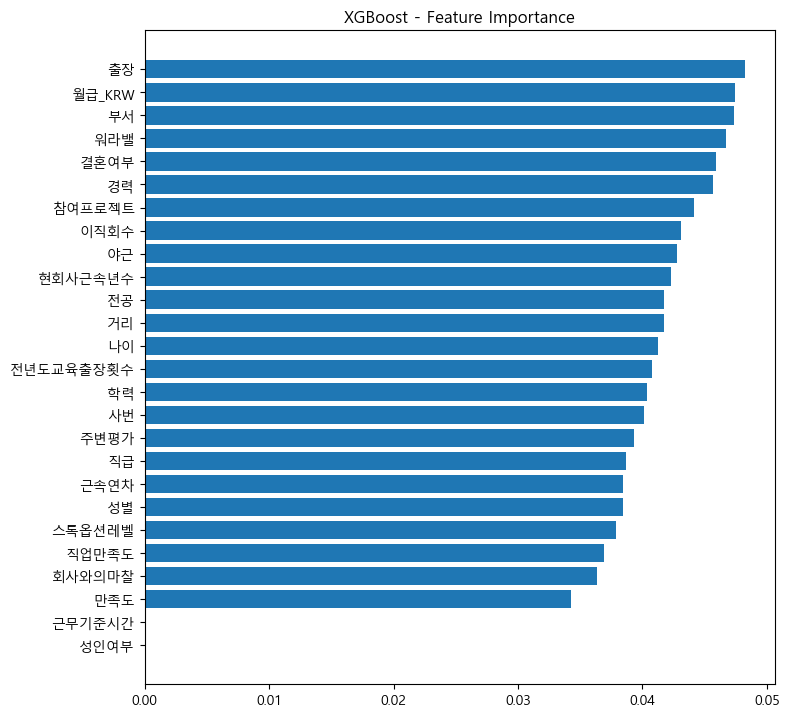


[XGBoost 중요도 순위]
01. 출장
02. 월급_KRW
03. 부서
04. 워라밸
05. 결혼여부
06. 경력
07. 참여프로젝트
08. 이직회수
09. 야근
10. 현회사근속년수
11. 전공
12. 거리
13. 나이
14. 전년도교육출장횟수
15. 학력
16. 사번
17. 주변평가
18. 직급
19. 근속연차
20. 성별
21. 스톡옵션레벨
22. 직업만족도
23. 회사와의마찰
24. 만족도
25. 근무기준시간
26. 성인여부


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier

try:
    from xgboost import XGBClassifier
    has_xgb = True
except Exception:
    has_xgb = False

try:
    from lightgbm import LGBMClassifier
    has_lgbm = True
except Exception:
    has_lgbm = False

# ===== 경로 & 환율 =====
INPATH = r"C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\인사평가.csv"
EXRATE_USD_KRW = 1380.0  # 최신환율값으로 반영이 필요 

# ===== 유틸 =====
def to_numeric_series(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s.astype(str).str.replace(",", ""), errors="coerce")

def normalize_currency(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip().str.upper()
    return s.replace({
        "달러": "USD", "US DOLLAR": "USD", "USD$": "USD", "$": "USD",
        "원": "KRW", "WON": "KRW", "KRW₩": "KRW", "￦": "KRW"
    })

# ===== 로드 =====
df = pd.read_csv(INPATH)

# ===== 타겟 =====
y_raw = df["업무평가"]
if y_raw.dtype == object:
    mapping = {"보통": 0, "좋다": 1, "좋음": 1}
    y = y_raw.map(mapping)
else:
    y = y_raw.copy()

# ===== 월급(USD) → KRW 변환 =====
if "월급" in df.columns:
    월급_num = to_numeric_series(df["월급"])

    if "통화" in df.columns:
        cur = normalize_currency(df["통화"])
        rate_map = {"USD": EXRATE_USD_KRW, "KRW": 1.0}
        cur_rate = cur.map(rate_map).fillna(EXRATE_USD_KRW)
        df["월급_KRW"] = 월급_num * cur_rate
    else:
        df["월급_KRW"] = 월급_num * EXRATE_USD_KRW
else:
    df["월급_KRW"] = np.nan

# ===== 원본 '월급' & '통화' 제거 =====
drop_cols = []
if "월급" in df.columns:
    drop_cols.append("월급")
if "통화" in df.columns:
    drop_cols.append("통화")

df = df.drop(columns=drop_cols)

# ===== 환율 반영 파일 저장 =====
out_csv = str(Path(INPATH).with_name(Path(INPATH).stem + "_환율적용.csv"))
df.to_csv(out_csv, index=False, encoding="utf-8-sig")
print(f"[저장완료] 환율 반영 파일: {out_csv}")

# ===== 피처 구성 =====
X = df.drop(columns=["업무평가"])
cat_cols = [c for c in X.columns if X[c].dtype == object]
num_cols = [c for c in X.columns if c not in cat_cols]

# ===== 전처리 =====
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ===== 학습 + 출력 =====
def fit_and_show(model_name, estimator):
    pipe = Pipeline([("prep", preprocessor), ("clf", estimator)])
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    pipe.fit(X_train, y_train)

    clf = pipe.named_steps["clf"]
    importances = getattr(clf, "feature_importances_", None)
    if importances is None:
        importances = getattr(getattr(clf, "booster_", clf), "feature_importances_", None)

    feat_names = pipe.named_steps["prep"].get_feature_names_out().tolist()
    fi = pd.DataFrame({"feature": feat_names, "importance": importances})
    fi = fi.sort_values("importance", ascending=False, ignore_index=True)
    fi["cumsum"] = fi["importance"].cumsum() / fi["importance"].sum()

    print(f"\n=== {model_name} Feature Importance ===")
    try:
        display(fi)
    except NameError:
        print(fi.head(30))

    plt.figure(figsize=(8, max(4, len(fi)*0.28)))
    plt.barh(fi["feature"][::-1], fi["importance"][::-1])
    plt.title(f"{model_name} - Feature Importance")
    plt.tight_layout()
    plt.show()

    return fi

# ===== 실행 =====
if has_xgb:
    fi_xgb = fit_and_show("XGBoost", XGBClassifier(
        n_estimators=600, learning_rate=0.05, max_depth=6,
        subsample=0.9, colsample_bytree=0.9, eval_metric="logloss",
        tree_method="hist", random_state=42, n_jobs=-1
    ))
    print("\n[XGBoost 중요도 순위]")
    for i, f in enumerate(fi_xgb["feature"], 1):
        print(f"{i:02d}. {f}")
else:
    print("XGBoost가 설치되어 있지 않아 RandomForest로 진행합니다.")
    fi_rf = fit_and_show("RandomForest", RandomForestClassifier(
        n_estimators=600, random_state=42, n_jobs=-1
    ))
    print("\n[RandomForest 중요도 순위]")
    for i, f in enumerate(fi_rf["feature"], 1):
        print(f"{i:02d}. {f}")


## 출장, 업무평가를 문자 -> 수치화

In [34]:
import pandas as pd
from pathlib import Path

# ===== 경로 =====
INPATH  = r"C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\인사평가_환율적용.csv"
OUTPATH = str(Path(INPATH).with_name(Path(INPATH).stem.replace("_환율적용","") + "_원핫출장구간.csv"))

# ===== 로드 =====
df = pd.read_csv(INPATH)

# ===== 타깃 숫자화 =====
if "업무평가" in df.columns and df["업무평가"].dtype == object:
    df["업무평가"] = df["업무평가"].map({"보통":0, "좋다":1, "좋음":1})

# ===== (수정) 1) 부서 → 원핫 인코딩 =====
if "부서" in df.columns:
    dept_dummies = pd.get_dummies(df["부서"], prefix="부서")
    df = pd.concat([df.drop(columns=["부서"]), dept_dummies], axis=1)

# ===== (수정) 2) 출장 → 구간화 (0회=0, 1~29=1, 30+ =2, 그 외/결측 = -1) =====
def encode_trip_text(s: pd.Series) -> pd.Series:
    x = s.astype(str).str.strip()
    x_norm = x.str.replace(" ", "", regex=False)

    map_dict = {
        "0회": 0, "없음": 0, "무": 0, "no": 0, "n": 0, "0": 0,
        "1~29회": 1, "1-29회": 1, "1~29": 1, "1-29": 1,
        "30회이상": 2, "30+": 2, "30이상": 2, "30회↑": 2
    }
    y = x_norm.map(map_dict)

    # 숫자형만 온 경우 처리 (예: "12")
    is_num = x_norm.str.fullmatch(r"\d+")
    num_vals = pd.to_numeric(x_norm[is_num], errors="coerce")
    y.loc[is_num & (num_vals == 0)] = 0
    y.loc[is_num & (num_vals.between(1, 29))] = 1
    y.loc[is_num & (num_vals >= 30)] = 2

    return y.fillna(-1).astype(int)

if "출장" in df.columns:
    df["출장"] = encode_trip_text(df["출장"])

# ===== 저장 =====
df.to_csv(OUTPATH, index=False, encoding="utf-8-sig")
print(f"[저장완료] {OUTPATH}")


[저장완료] C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\인사평가_원핫출장구간.csv


## 라벨인코딩 이후 피쳐임포턴스 체크 확인 및 cumsum 확인

[저장완료] 환율 반영 파일: C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\인사평가_환율적용.csv
[저장완료] 라벨 인코딩 파일: C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\인사평가_라벨인코딩.csv

[RandomForest] Test Accuracy: 0.8469
=== RandomForest Feature Importance (Top 20) ===
      feature  importance    cumsum
0          사번    0.112840  0.112840
1      월급_KRW    0.104510  0.217351
2          나이    0.080419  0.297770
3          거리    0.068918  0.366687
4          경력    0.066126  0.432814
5     현회사근속년수    0.064267  0.497081
6        이직회수    0.045410  0.542491
7   전년도교육출장횟수    0.040560  0.583050
8          직급    0.039926  0.622976
9          학력    0.038129  0.661105
10      직업만족도    0.034452  0.695557
11        만족도    0.034332  0.729889
12       주변평가    0.032441  0.762331
13         전공    0.031691  0.794022
14     참여프로젝트    0.030083  0.824105
15        워라밸    0.026986  0.851091
16     스톡옵션레벨    0.026028  0.877120
17         출장    0.024306  0.901425
18       결혼여부    0.023110  0.924536
19       근속연차    0.020178  0.944713


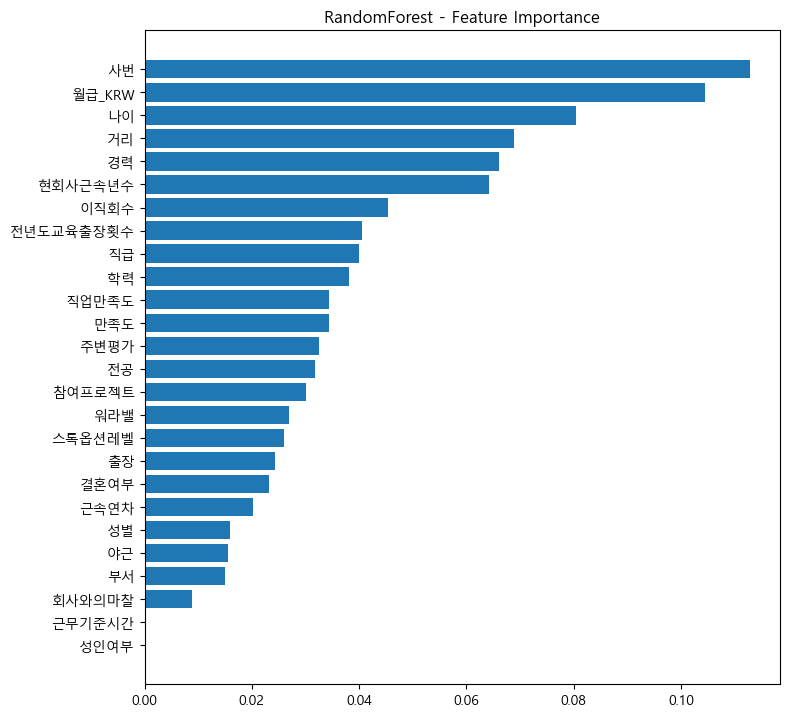


[XGBoost] Test Accuracy: 0.8333
=== XGBoost Feature Importance (Top 20) ===
    feature  importance    cumsum
0        야근    0.050358  0.050358
1        부서    0.046554  0.096913
2      주변평가    0.046211  0.143123
3       워라밸    0.046031  0.189154
4    월급_KRW    0.045754  0.234908
5    회사와의마찰    0.045540  0.280447
6        출장    0.045511  0.325959
7   현회사근속년수    0.044138  0.370096
8        나이    0.042990  0.413087
9      결혼여부    0.042880  0.455967
10       경력    0.042683  0.498650
11       학력    0.042363  0.541013
12       전공    0.041593  0.582605
13     이직회수    0.041025  0.623630
14       직급    0.040735  0.664366
15       거리    0.039862  0.704228
16   참여프로젝트    0.039669  0.743896
17   스톡옵션레벨    0.039120  0.783017
18       사번    0.039032  0.822049
19    직업만족도    0.037768  0.859818


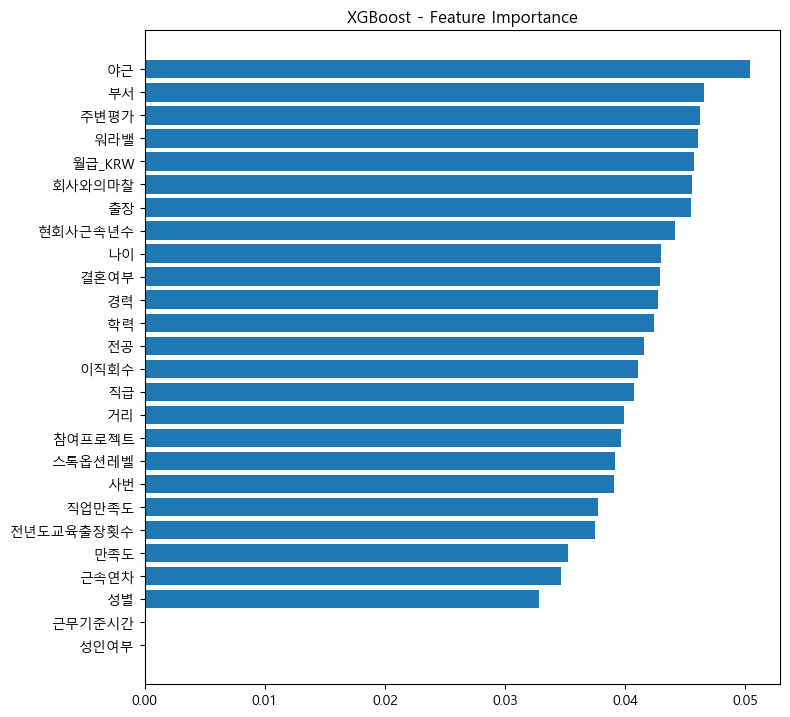

In [35]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ===== 옵션: XGBoost 사용 가능 여부 =====
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# ===== 경로 & 환율 =====
INPATH  = r"C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\인사평가.csv"  # 원본
EXRATE_USD_KRW = 1380.0  # 최신 환율로 수정 가능

OUT_EXRATE = str(Path(INPATH).with_name(Path(INPATH).stem + "_환율적용.csv"))
OUT_LABEL  = str(Path(INPATH).with_name(Path(INPATH).stem + "_라벨인코딩.csv"))

# ===== 유틸 =====
def to_numeric_series(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s.astype(str).str.replace(",", ""), errors="coerce")

def normalize_currency(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip().str.upper()
    return s.replace({
        "달러":"USD", "US DOLLAR":"USD", "USD$":"USD", "$":"USD",
        "원":"KRW", "WON":"KRW", "KRW₩":"KRW", "￦":"KRW"
    })

def encode_trip_text(s: pd.Series) -> pd.Series:
    """출장: 0회→0, 1~29회→1, 30회 이상→2, 그 외/결측→-1"""
    x = s.astype(str).str.strip()
    x_norm = x.str.replace(" ", "", regex=False)

    map_dict = {
        "0회":0, "없음":0, "무":0, "no":0, "n":0, "0":0,
        "1~29회":1, "1-29회":1, "1~29":1, "1-29":1,
        "30회이상":2, "30+":2, "30이상":2, "30회↑":2
    }
    y = x_norm.map(map_dict)

    # 숫자만 온 경우(예: "12")
    is_num = x_norm.str.fullmatch(r"\d+")
    num_vals = pd.to_numeric(x_norm[is_num], errors="coerce")
    y.loc[is_num & (num_vals == 0)] = 0
    y.loc[is_num & (num_vals.between(1, 29))] = 1
    y.loc[is_num & (num_vals >= 30)] = 2

    return y.fillna(-1).astype(int)

# ===== 1) 환율 적용 & 저장 =====
df = pd.read_csv(INPATH)

# 타깃(업무평가) 숫자화 준비용 복사
y_raw = df["업무평가"] if "업무평가" in df.columns else None

# 월급 → KRW
if "월급" in df.columns:
    월급_num = to_numeric_series(df["월급"])
    if "통화" in df.columns:
        cur = normalize_currency(df["통화"])
        rate_map = {"USD": EXRATE_USD_KRW, "KRW": 1.0}
        cur_rate = cur.map(rate_map).fillna(EXRATE_USD_KRW)
        df["월급_KRW"] = 월급_num * cur_rate
    else:
        df["월급_KRW"] = 월급_num * EXRATE_USD_KRW
else:
    df["월급_KRW"] = np.nan

# 원본 월급/통화 제거
drop_cols = []
if "월급" in df.columns:   drop_cols.append("월급")
if "통화" in df.columns:   drop_cols.append("통화")
if drop_cols:
    df.drop(columns=drop_cols, inplace=True)

# 환율 적용 저장
df.to_csv(OUT_EXRATE, index=False, encoding="utf-8-sig")
print(f"[저장완료] 환율 반영 파일: {OUT_EXRATE}")

# ===== 2) 부서/출장 '값 교체' 인코딩 & 저장 =====
# 타깃 숫자화 (문자면 매핑)
if "업무평가" in df.columns and df["업무평가"].dtype == object:
    df["업무평가"] = df["업무평가"].map({"보통":0, "좋다":1, "좋음":1})

# 부서: 0=R&D, 1=영업, 2=사무직, 그 외/결측=-1
dept_map = {"R&D":0, "영업":1, "사무직":2}
if "부서" in df.columns:
    df["부서"] = df["부서"].map(dept_map).fillna(-1).astype(int)

# 출장: 문자 → 0/1/2
if "출장" in df.columns:
    df["출장"] = encode_trip_text(df["출장"])

# 저장
df.to_csv(OUT_LABEL, index=False, encoding="utf-8-sig")
print(f"[저장완료] 라벨 인코딩 파일: {OUT_LABEL}")

# ===== 3) 학습/평가(정확도, 중요도) =====
# 데이터 로드
df = pd.read_csv(OUT_LABEL)

# 타깃/피처
assert "업무평가" in df.columns, "타깃 '업무평가'가 없습니다."
y = df["업무평가"]
X = df.drop(columns=["업무평가"])

# 남은 범주형 자동 인코딩(있을 때만)
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

# 전처리
transformers = [("num", SimpleImputer(strategy="median"), num_cols)]
if len(cat_cols) > 0:
    cat_pipe = Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ])
    transformers.append(("cat", cat_pipe, cat_cols))

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
    verbose_feature_names_out=False
)

def fit_and_show(model_name, estimator):
    pipe = Pipeline([("prep", preprocessor), ("clf", estimator)])
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    pipe.fit(X_train, y_train)

    # 성능
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n[{model_name}] Test Accuracy: {acc:.4f}")

    # 중요도
    clf = pipe.named_steps["clf"]
    importances = getattr(clf, "feature_importances_", None)
    if importances is None:
        importances = getattr(getattr(clf, "booster_", clf), "feature_importances_", None)

    feat_names = pipe.named_steps["prep"].get_feature_names_out().tolist()
    fi = pd.DataFrame({"feature": feat_names, "importance": importances})
    fi = fi.sort_values("importance", ascending=False, ignore_index=True)
    fi["cumsum"] = fi["importance"].cumsum() / fi["importance"].sum()

    print(f"=== {model_name} Feature Importance (Top 20) ===")
    print(fi.head(20))

    plt.figure(figsize=(8, max(4, len(fi)*0.28)))
    plt.barh(fi["feature"][::-1], fi["importance"][::-1])
    plt.title(f"{model_name} - Feature Importance")
    plt.tight_layout()
    plt.show()

    return fi

# 실행: RandomForest (기본)
fi_rf = fit_and_show("RandomForest", RandomForestClassifier(
    n_estimators=600, random_state=42, n_jobs=-1
))

# 실행: XGBoost (설치돼 있으면)
if HAS_XGB:
    fi_xgb = fit_and_show("XGBoost", XGBClassifier(
        n_estimators=600, learning_rate=0.05, max_depth=6,
        subsample=0.9, colsample_bytree=0.9, eval_metric="logloss",
        tree_method="hist", random_state=42, n_jobs=-1
    ))


## 피쳐 정리및 열 내용 수정
 - 제거한 항목 : 사본, 근무기준시간, 나이, 거리, 성별, 성인여부, 야근, 학력, 만족도, 직업만족도, 워라벨, 회사와의마찰, 스톡옵션레벨, 직급, 결혼여부

In [36]:
# -*- coding: utf-8 -*-
import pandas as pd

# 1) 원본 CSV 불러오기
INPATH  = r"C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\인사평가_라벨인코딩.csv"
OUTPATH = r"C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\\인사평가_clean.csv"

df = pd.read_csv(INPATH)

# 2) 직급 → 관리자 여부 파생변수 생성
df["직급관리자여부"] = df["직급"].astype(str).apply(
    lambda s: 1 if ("관리자" in s or "책임자" in s) else 0
)

# 3) 제거할 열 정의
drop_cols = [
    "사번", "근무기준시간", "나이", "거리", "성별", "성인여부", "야근", "학력",
    "만족도", "직업만족도", "워라밸", "회사와의마찰", "스톡옵션레벨", "직급", "결혼여부"
]

# 실제 존재하는 열만 제거
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# 4) 새로운 CSV로 저장
df.to_csv(OUTPATH, index=False, encoding="utf-8-sig")

print(f"[저장 완료] {OUTPATH}")
print("최종 컬럼:", df.columns.tolist())


[저장 완료] C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\\인사평가_clean.csv
최종 컬럼: ['출장', '부서', '전공', '참여프로젝트', '근속연차', '이직회수', '업무평가', '주변평가', '경력', '전년도교육출장횟수', '현회사근속년수', '월급_KRW', '직급관리자여부']


## 피쳐 항목 제거 후 random forest 의 피쳐 임포턴스 체크

      feature  importance
0      월급_KRW    0.242113
1          경력    0.133009
2     현회사근속년수    0.123996
3        이직회수    0.088294
4   전년도교육출장횟수    0.081670
5        주변평가    0.072041
6          전공    0.065345
7      참여프로젝트    0.060959
8          출장    0.046075
9          부서    0.034473
10       근속연차    0.033996
11    직급관리자여부    0.018028


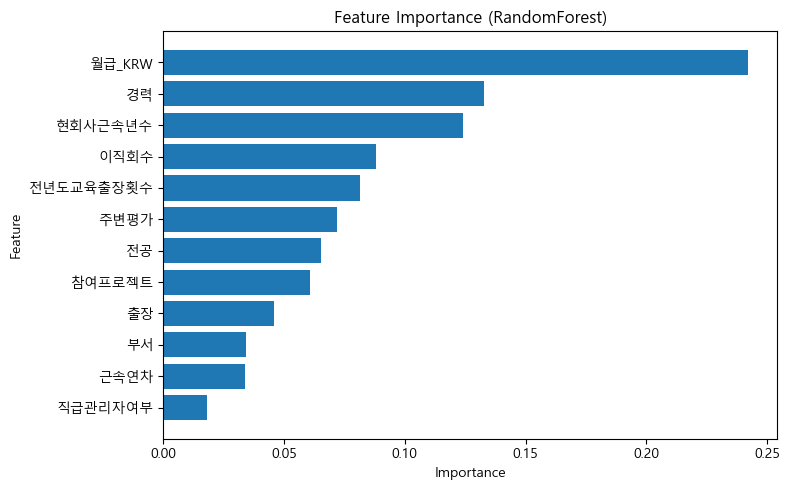

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier

# 1) 경로 설정 (clean csv 불러오기)
INPATH  = r"C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\인사평가_clean.csv"
df = pd.read_csv(INPATH)

# 2) X, y 분리
y = df["업무평가"]
X = df.drop(columns=["업무평가"])

# 3) 범주형 / 수치형 구분
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

# 4) 전처리 파이프라인
cat_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

num_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("cat", cat_tf, cat_cols),
        ("num", num_tf, num_cols)
    ]
)

# 5) 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 6) RandomForest 모델 학습
rf = Pipeline(steps=[
    ("pp", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ))
])
rf.fit(X_train, y_train)

# 7) 피처 중요도 추출
# (전처리 후 feature_names 직접 구성)
feature_names = cat_cols + num_cols
importances = rf.named_steps["clf"].feature_importances_

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

print(fi)

# 8) 시각화
plt.figure(figsize=(8,5))
plt.barh(fi["feature"][:15][::-1], fi["importance"][:15][::-1])
plt.title("Feature Importance (RandomForest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 피쳐 항목 제거 후 XGboost 피처 임포턴스 체크

      feature  importance
0          출장    0.104961
1          부서    0.089282
2     직급관리자여부    0.088711
3        이직회수    0.085446
4          경력    0.085304
5      월급_KRW    0.082791
6   전년도교육출장횟수    0.080855
7     현회사근속년수    0.080615
8          전공    0.080199
9      참여프로젝트    0.077225
10       주변평가    0.076939
11       근속연차    0.067671


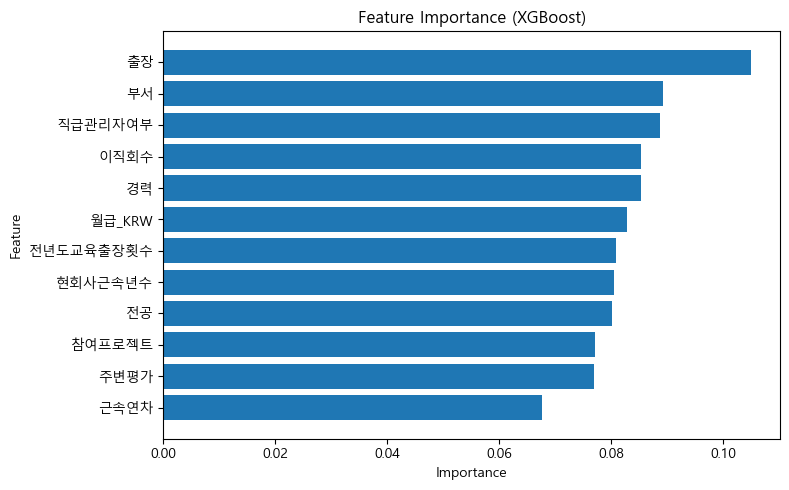

In [38]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBClassifier, plot_importance

# 1) CSV 불러오기 (전처리된 clean 버전)
INPATH = r"C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\인사평가_clean.csv"
df = pd.read_csv(INPATH)

# 2) 타깃/피처 분리
y = df["업무평가"]
X = df.drop(columns=["업무평가"])

# 3) 범주형/수치형 분리
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

# 4) 전처리 파이프라인
cat_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

num_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preprocess = ColumnTransformer([
    ("cat", cat_tf, cat_cols),
    ("num", num_tf, num_cols)
])

# 5) 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 6) XGBoost 모델
xgb = Pipeline(steps=[
    ("pp", preprocess),
    ("clf", XGBClassifier(
        n_estimators=800,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

# 7) 학습
xgb.fit(X_train, y_train)

# 8) 피처 중요도 추출
# 전처리 후 feature name 직접 구성
feature_names = cat_cols + num_cols
booster = xgb.named_steps["clf"]

importances = booster.feature_importances_

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

print(fi)

# 9) 시각화 (Top 15)
plt.figure(figsize=(8,5))
plt.barh(fi["feature"][:15][::-1], fi["importance"][:15][::-1])
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 피쳐 생성1
- 월급_경력비, 월급-프로젝트비
- 현근속_총경력비, 총근속, 경력성장률
- 이직빈도, 학습몰입도

In [39]:
import pandas as pd
from pathlib import Path

# ===== 경로 (방법 2 raw string 사용 예시) =====
INPUT_CSV  = r"C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\인사평가_clean.csv"
OUTPUT_CSV = str(Path(INPUT_CSV).with_name("인사평가_feature_engineered.csv"))

# ===== 데이터 로드 =====
df = pd.read_csv(INPUT_CSV)

# ===== 파생변수 생성 =====
df["월급_경력비"]    = df["월급_KRW"] / (df["경력"] + 1)
df["월급_프로젝트비"] = df["월급_KRW"] / (df["참여프로젝트"] + 1)

df["현근속_총경력비"] = df["현회사근속년수"] / (df["경력"] + 1)

df["총근속"]     = df["현회사근속년수"] + (df["근속연차"] - df["현회사근속년수"])
df["경력성장률"] = df["현회사근속년수"] / (df["근속연차"] + 1)

df["이직빈도"]  = df["이직회수"] / (df["경력"] + 1)
df["학습몰입도"] = df["참여프로젝트"] * df["전년도교육출장횟수"]

# ===== 저장 =====
df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
print(f"[완료] 새로운 피처가 추가된 CSV 저장됨: {OUTPUT_CSV}")


[완료] 새로운 피처가 추가된 CSV 저장됨: C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\인사평가_feature_engineered.csv


## 피쳐생성 2
- 월급_근속연차비
- 월급_출장비
- 근속_경력비
- 평균근속기간
- 프로젝트_경력비
- 프로젝트_근속연차비
- 출장_경력비
- 출장_근속연차비
- 교육출장_경력비
- 주변평가_근속연차
- 학습몰입도_교육출장

In [40]:
import pandas as pd
import numpy as np

# ===== 파일 경로 =====
IN_CSV  = r"C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\인사평가_feature_engineered.csv"
OUT_CSV = r"C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\인사평가_feature_engineered_plus.csv"

# ===== 데이터 로드 =====
df = pd.read_csv(IN_CSV)

def safe_div(a, b):
    """0 나눔 방지"""
    return a / b.replace(0, np.nan) if isinstance(b, pd.Series) else (np.nan if b==0 else a/b)

# ===== 파생변수 생성 =====
df["월급_근속연차비"]   = safe_div(df["월급_KRW"], (df["근속연차"] + 1))
df["월급_출장비"]       = safe_div(df["월급_KRW"], (df["출장"] + 1))

df["근속_경력비"]       = safe_div(df["현회사근속년수"], (df["경력"] + 1))
df["평균근속기간"]       = safe_div(df["총근속"], (df["이직회수"] + 1))

df["프로젝트_경력비"]     = safe_div(df["참여프로젝트"], (df["경력"] + 1))
df["프로젝트_근속연차비"] = safe_div(df["참여프로젝트"], (df["근속연차"] + 1))
df["출장_경력비"]        = safe_div(df["출장"], (df["경력"] + 1))
df["출장_근속연차비"]     = safe_div(df["출장"], (df["근속연차"] + 1))
df["교육출장_경력비"]     = safe_div(df["전년도교육출장횟수"], (df["경력"] + 1))

df["주변평가_근속연차"]   = df["주변평가"] * df["근속연차"]
df["학습몰입도_교육출장"] = df["학습몰입도"] * df["전년도교육출장횟수"]

# ===== 저장 =====
df.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")
print(f"[저장 완료] {OUT_CSV}")


[저장 완료] C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\인사평가_feature_engineered_plus.csv


## 수정된 피쳐의 피쳐 임포턴스(XGBoost)

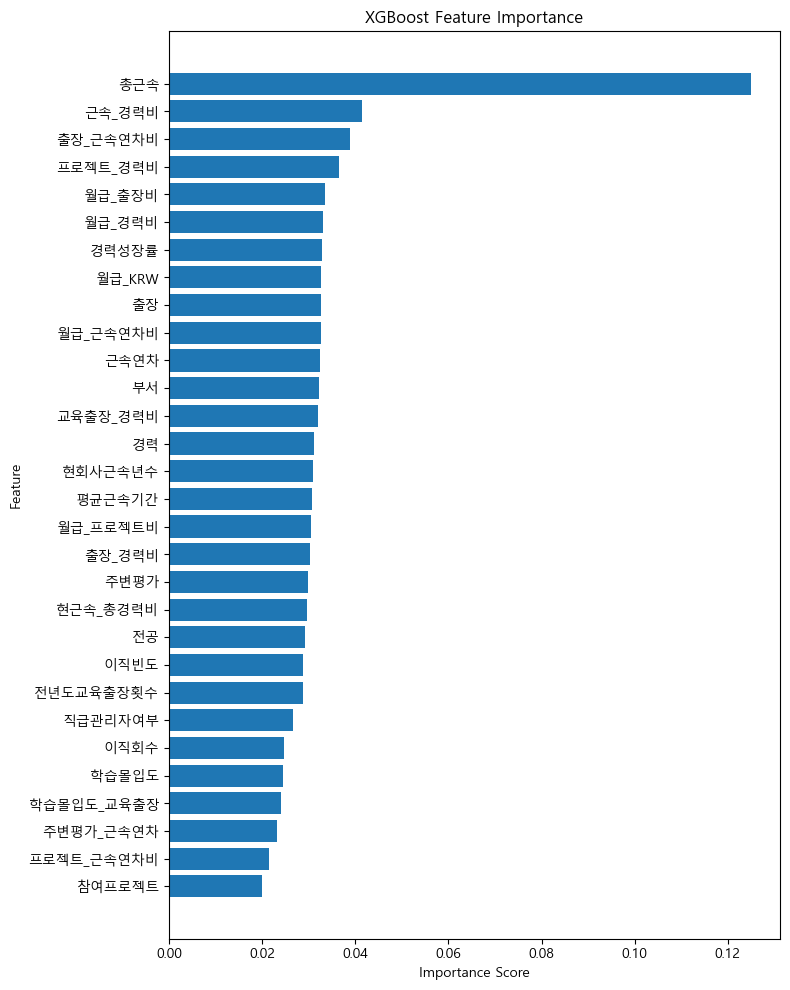

     feature  importance
15       총근속    0.124966
21    근속_경력비    0.041537
26  출장_근속연차비    0.038957
23  프로젝트_경력비    0.036406
20    월급_출장비    0.033462
12    월급_경력비    0.032967
16     경력성장률    0.032951
10    월급_KRW    0.032681
1         출장    0.032665
19  월급_근속연차비    0.032583
4       근속연차    0.032434
2         부서    0.032221
27  교육출장_경력비    0.032061
7         경력    0.031223
9    현회사근속년수    0.030875
22    평균근속기간    0.030615
13  월급_프로젝트비    0.030578
25    출장_경력비    0.030218
6       주변평가    0.029762
14  현근속_총경력비    0.029563


In [41]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier

# ====== 경로 ======
INPUT_CSV = r"C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\인사평가_feature_engineered_plus.csv"

# ====== 데이터 로드 ======
df = pd.read_csv(INPUT_CSV)

# ====== 타깃 선택 (업무평가2 있으면 그걸, 없으면 업무평가 사용) ======
target_col = "업무평가2" if "업무평가2" in df.columns else "업무평가"
y = df[target_col]
X = df.drop(columns=[target_col])

# ====== 범주형 / 수치형 구분 ======
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

# ====== 전처리 파이프라인 ======
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer([
    ("cat", cat_pipe, cat_cols),
    ("num", num_pipe, num_cols)
])

# ====== 데이터 분할 ======
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ====== 모델 정의 및 학습 ======
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb)
])

pipe.fit(X_train, y_train)

# ====== 피처 중요도 DataFrame ======
xgb_model = pipe.named_steps["model"]
features = cat_cols + num_cols
importances = xgb_model.feature_importances_

feat_importance_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=True)   # 그래프 보기 좋게 오름차순

# ====== 시각화 (y축에 피처 이름) ======
plt.figure(figsize=(8, 10))
plt.barh(feat_importance_df["feature"], feat_importance_df["importance"])
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

# ====== 상위 20개 출력 ======
print(feat_importance_df.sort_values(by="importance", ascending=False).head(20))


## 수정된 피쳐의 cumsum

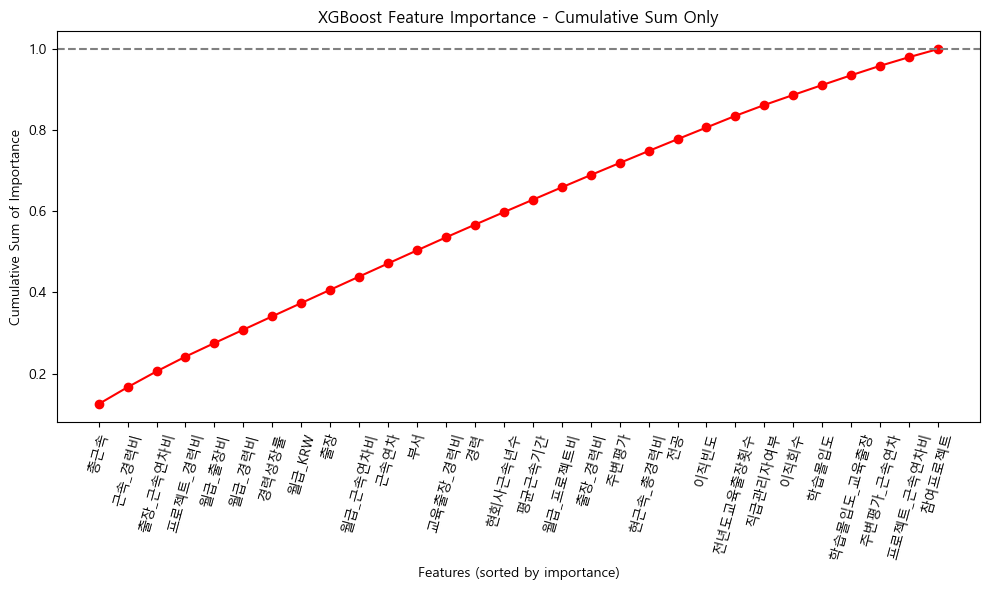

     feature    cumsum
0        총근속  0.124966
1     근속_경력비  0.166503
2   출장_근속연차비  0.205461
3   프로젝트_경력비  0.241867
4     월급_출장비  0.275329
5     월급_경력비  0.308296
6      경력성장률  0.341247
7     월급_KRW  0.373928
8         출장  0.406593
9   월급_근속연차비  0.439176
10      근속연차  0.471609
11        부서  0.503830
12  교육출장_경력비  0.535891
13        경력  0.567115
14   현회사근속년수  0.597989
15    평균근속기간  0.628604
16  월급_프로젝트비  0.659182
17    출장_경력비  0.689400
18      주변평가  0.719162
19  현근속_총경력비  0.748725


In [42]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier

# ====== 경로 ======
INPUT_CSV = r"C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\인사평가_feature_engineered_plus.csv"

# ====== 데이터 로드 ======
df = pd.read_csv(INPUT_CSV)

# ====== 타깃 선택 ======
target_col = "업무평가2" if "업무평가2" in df.columns else "업무평가"
y = df[target_col]
X = df.drop(columns=[target_col])

# ====== 범주형 / 수치형 구분 ======
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

# ====== 전처리 ======
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])
num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])
preprocessor = ColumnTransformer([("cat", cat_pipe, cat_cols),
                                  ("num", num_pipe, num_cols)])

# ====== 데이터 분할 ======
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ====== 모델 ======
xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, use_label_encoder=False, eval_metric="logloss"
)
pipe = Pipeline([("preprocessor", preprocessor), ("model", xgb)])
pipe.fit(X_train, y_train)

# ====== 누적합만 계산 ======
xgb_model = pipe.named_steps["model"]
features = cat_cols + num_cols
importances = xgb_model.feature_importances_

# 중요도 높은 순으로 정렬 후 누적합
feat_df = pd.DataFrame({"feature": features, "importance": importances})
feat_df = feat_df.sort_values(by="importance", ascending=False).reset_index(drop=True)
feat_df["cumsum"] = feat_df["importance"].cumsum()

# ====== 누적합 그래프 ======
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(feat_df) + 1), feat_df["cumsum"], marker="o", color="red")
plt.axhline(y=1.0, color="gray", linestyle="--")  # 최대선
plt.xticks(range(1, len(feat_df) + 1), feat_df["feature"], rotation=75)
plt.ylabel("Cumulative Sum of Importance")
plt.xlabel("Features (sorted by importance)")
plt.title("XGBoost Feature Importance - Cumulative Sum Only")
plt.tight_layout()
plt.show()

# ====== 상위 20개 누적합 출력 ======
print(feat_df.head(20)[["feature", "cumsum"]])


## (학습)XGBoost + Borderline-SMOTE  사용

In [43]:

import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, ConfusionMatrixDisplay

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import BorderlineSMOTE
from xgboost import XGBClassifier

# ===== 경로/설정 =====
INPUT_CSV = r"C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\인사평가_feature_engineered_plus.csv"
FIXED_THRESHOLD = 0.84  # 필요 시 조정
OUTDIR = Path(INPUT_CSV).with_name("학습결과_BSMOTE")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ===== 데이터 =====
if not os.path.exists(INPUT_CSV):
    raise FileNotFoundError(f"입력 CSV가 없습니다: {INPUT_CSV}")
df = pd.read_csv(INPUT_CSV)

if "업무평가" not in df.columns:
    raise KeyError("'업무평가' 열이 없습니다.")

# 타깃 매핑: 보통/0 -> 0, 좋다/좋음/1 -> 1
y = (df["업무평가"].astype(str).str.strip().str.lower()
     .map({"보통":0, "0":0, "좋다":1, "좋음":1, "1":1}).astype(int))
X = df.drop(columns=["업무평가"])

# 범주/수치 분리
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

# 전처리
numeric_tf = SimpleImputer(strategy="median")
categorical_tf = ImbPipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])
preprocess = ColumnTransformer([
    ("num", numeric_tf, num_cols),
    ("cat", categorical_tf, cat_cols),
])

# 학습/검증 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 모델
xgb = XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.07,
    subsample=0.9, colsample_bytree=0.9,
    objective="binary:logistic", eval_metric="logloss",
    random_state=42, n_jobs=-1, tree_method="hist"
)

# 파이프라인 (Borderline-SMOTE 포함)
model = ImbPipeline([
    ("preprocess", preprocess),
    ("bsmote", BorderlineSMOTE(random_state=42)),
    ("clf", xgb),
])

# 학습
model.fit(X_train, y_train)

# 평가 (고정 임계값)
proba = model.predict_proba(X_test)[:, 1]
pred  = (proba >= FIXED_THRESHOLD).astype(int)

acc   = accuracy_score(y_test, pred)
prec0 = precision_score(y_test, pred, pos_label=0, zero_division=0)
prec1 = precision_score(y_test, pred, pos_label=1, zero_division=0)

print("[Result]")
print(f"Used threshold : {FIXED_THRESHOLD:.2f}")
print(f"Accuracy       : {acc:.4f}")
print(f"Precision(0)   : {prec0:.4f}")
print(f"Precision(1)   : {prec1:.4f}")

# 혼동행렬 저장
cm = confusion_matrix(y_test, pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(values_format="d", cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix @ th={FIXED_THRESHOLD:.2f}")
plt.tight_layout()
plt.savefig(OUTDIR / "confusion_matrix.png", dpi=150)
plt.close()

print(f"\n[저장 완료] {OUTDIR}/confusion_matrix.png")


[Result]
Used threshold : 0.84
Accuracy       : 0.8537
Precision(0)   : 0.8527
Precision(1)   : 1.0000

[저장 완료] C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\학습결과_BSMOTE/confusion_matrix.png


## 학습저장

In [44]:
import joblib
from pathlib import Path

OUTDIR = Path(r"C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\학습결과_BSMOTE")
OUTDIR.mkdir(parents=True, exist_ok=True)

PKL_PATH = OUTDIR / "final_model.pkl"

# model 객체 + threshold + meta 한 번에 묶어서 저장
package = {
    "model": model,             # 학습된 파이프라인
    "threshold": 0.84,          # FIXED_THRESHOLD
    "cat_cols": cat_cols,       # 범주형 칼럼
    "num_cols": num_cols        # 수치형 칼럼
}
joblib.dump(package, PKL_PATH)

print(f"[저장 완료] {PKL_PATH}")


[저장 완료] C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\학습결과_BSMOTE\final_model.pkl


In [45]:
import joblib
from pathlib import Path

OUTDIR = Path(r"C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\학습결과_BSMOTE")
OUTDIR.mkdir(parents=True, exist_ok=True)

PKL_PATH = OUTDIR / "final_model.pkl"

package = {
    "model": model,        # 이미 학습된 파이프라인
    "threshold": 0.84,     # FIXED_THRESHOLD
    "cat_cols": cat_cols,
    "num_cols": num_cols
}
joblib.dump(package, PKL_PATH)
print(f"[저장 완료] {PKL_PATH}")


[저장 완료] C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\학습결과_BSMOTE\final_model.pkl


In [ ]:
import joblib
import pandas as pd
import numpy as np

PKL_PATH = r"C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\학습결과_BSMOTE\final_model.pkl"
package   = joblib.load(PKL_PATH)
model     = package["model"]
th        = package["threshold"]
num_cols  = list(package["num_cols"])
cat_cols  = list(package["cat_cols"])


BASE_INPUT_COLS = [
    "출장", "전년도교육출장횟수", "이직회수", "참여프로젝트", "월급_KRW", "경력",
    "현회사근속년수", "근속연차", "주변평가", "부서", "전공", "직급관리자여부"
]

# 전공 허용 목록 (CSV 기준)
MAJOR_ALLOWED = ["공학계열","자연과학계열","사회과학계열","상경계열","인문학","기타"]

def safe_div_series(a: pd.Series, b: pd.Series) -> pd.Series:
    a_ = pd.to_numeric(a, errors="coerce")
    b_ = pd.to_numeric(b, errors="coerce").replace(0, np.nan)
    return a_ / b_

def _input_with_guide(col: str):
    """원본 컬럼 입력 규칙"""
    # 출장: 실제 횟수(정수)
    if col == "출장":
        while True:
            val = input(f"{col} 값 입력 (정수, 실제 출장 횟수): ").strip()
            try:
                iv = int(val)
                if iv < 0:
                    print(" 음수는 허용되지 않습니다.")
                    continue
                return iv
            except:
                print(" 정수로 입력하세요.")

    # 전년도교육출장횟수 (정수)
    if col == "전년도교육출장횟수":
        while True:
            val = input(f"{col} 값 입력 (정수, 실제 횟수): ").strip()
            try:
                iv = int(val)
                if iv < 0:
                    print(" 음수는 허용되지 않습니다.")
                    continue
                return iv
            except:
                print(" 정수로 입력하세요.")

    # 주변평가 (1~4)
    if col == "주변평가":
        while True:
            val = input(f"{col} 값 입력 (1=매우 낮음, 2=보통, 3=좋음, 4=매우 좋음): ").strip()
            if val in {"1","2","3","4"}:
                return int(val)
            print(" 1~4 사이 정수만 허용됩니다.")

    # 전공 (고정 셋)
    if col == "전공":
        while True:
            val = input(f"{col} 값 입력 (선택지: {', '.join(MAJOR_ALLOWED)}): ").strip()
            if val in MAJOR_ALLOWED:
                return val
            print("목록 중 하나를 정확히 입력하세요.")

    # 부서 (0=R&D, 1=영업, 2=사무직)
    if col == "부서":
        while True:
            val = input(f"{col} 값 입력 (0=R&D, 1=영업, 2=사무직): ").strip()
            if val in {"0","1","2"}:
                return int(val)
            print(" 0/1/2 중에서만 입력하세요.")

    # 직급관리자여부 (0/1)
    if col == "직급관리자여부":
        while True:
            val = input(f"{col} 값 입력 (0=일반직, 1=관리직 이상): ").strip()
            if val in {"0","1"}:
                return int(val)
            print(" 0 또는 1만 허용됩니다.")

    # 일반 수치형
    if col in {"월급_KRW","경력","근속연차","이직회수","참여프로젝트","현회사근속년수"}:
        raw = input(f"{col} 값 입력 (숫자, 미입력 시 Enter): ").strip()
        if raw == "":
            return np.nan
        try:
            return float(raw)
        except:
            print(" 숫자로 변환할 수 없어 NaN으로 처리됩니다.")
            return np.nan

    # 예외(보수적)
    raw = input(f"{col} 값 입력: ").strip()
    try:
        return float(raw)
    except:
        return raw if raw != "" else None

def _compute_known_derived(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    expected = set(num_cols + cat_cols)

    # ── 근속/경력 관련 ───────────────────────────────────────────
    if "총근속" in expected and "근속연차" in out.columns:
        out["총근속"] = pd.to_numeric(out["근속연차"], errors="coerce")

    if "평균근속기간" in expected and {"경력","이직회수"}.issubset(out.columns):
        num_ = pd.to_numeric(out["경력"], errors="coerce")
        den_ = pd.to_numeric(out["이직회수"], errors="coerce") + 1
        den_.replace(0, np.nan, inplace=True)
        out["평균근속기간"] = num_ / den_

    if "현근속_총경력비" in expected and {"현회사근속년수","경력"}.issubset(out.columns):
        out["현근속_총경력비"] = safe_div_series(out["현회사근속년수"], out["경력"])

    if "근속_경력비" in expected and {"근속연차","경력"}.issubset(out.columns):
        out["근속_경력비"] = safe_div_series(out["근속연차"], out["경력"])

    if "경력성장률" in expected and {"경력","근속연차"}.issubset(out.columns):
        out["경력성장률"] = safe_div_series(out["경력"], out["근속연차"])

    if "이직빈도" in expected and {"이직회수","경력"}.issubset(out.columns):
        out["이직빈도"] = safe_div_series(out["이직회수"], out["경력"])

    # ── 프로젝트/출장/교육 관련 ────────────────────────────────
    if "학습몰입도" in expected and {"참여프로젝트","전년도교육출장횟수"}.issubset(out.columns):
        out["학습몰입도"] = (
            pd.to_numeric(out["참여프로젝트"], errors="coerce") *
            pd.to_numeric(out["전년도교육출장횟수"], errors="coerce")
        )

    # 출장 파생(실제 출장 횟수 기반)
    if "출장_경력비" in expected and {"출장","경력"}.issubset(out.columns):
        out["출장_경력비"] = safe_div_series(out["출장"], out["경력"])

    if "출장_근속연차비" in expected and {"출장","근속연차"}.issubset(out.columns):
        out["출장_근속연차비"] = safe_div_series(out["출장"], out["근속연차"])

    # 프로젝트 비율
    if "프로젝트_경력비" in expected and {"참여프로젝트","경력"}.issubset(out.columns):
        out["프로젝트_경력비"] = safe_div_series(out["참여프로젝트"], out["경력"])

    if "프로젝트_근속연차비" in expected and {"참여프로젝트","근속연차"}.issubset(out.columns):
        out["프로젝트_근속연차비"] = safe_div_series(out["참여프로젝트"], out["근속연차"])

    # 교육출장 비율
    if "교육출장_경력비" in expected and {"전년도교육출장횟수","경력"}.issubset(out.columns):
        out["교육출장_경력비"] = safe_div_series(out["전년도교육출장횟수"], out["경력"])
        # ── 학습몰입도 (참여프로젝트 × 전년도교육출장횟수)
    if "학습몰입도" in expected and {"참여프로젝트","전년도교육출장횟수"}.issubset(out.columns):
        out["학습몰입도"] = (
            pd.to_numeric(out["참여프로젝트"], errors="coerce") *
            pd.to_numeric(out["전년도교육출장횟수"], errors="coerce")
        )

    # ── 학습몰입도_교육출장 (학습몰입도 × 전년도교육출장횟수)
    if "학습몰입도_교육출장" in expected and {"학습몰입도","전년도교육출장횟수"}.issubset(out.columns):
        out["학습몰입도_교육출장"] = (
            pd.to_numeric(out["학습몰입도"], errors="coerce") *
            pd.to_numeric(out["전년도교육출장횟수"], errors="coerce")
        )


    # ── 월급_KRW 기반 파생 ─────────────────────────────────────
    if "월급_경력비" in expected and {"월급_KRW","경력"}.issubset(out.columns):
        out["월급_경력비"] = safe_div_series(out["월급_KRW"], out["경력"])

    if "월급_프로젝트비" in expected and {"월급_KRW","참여프로젝트"}.issubset(out.columns):
        out["월급_프로젝트비"] = safe_div_series(out["월급_KRW"], out["참여프로젝트"])

    if "월급_근속연차비" in expected and {"월급_KRW","근속연차"}.issubset(out.columns):
        out["월급_근속연차비"] = safe_div_series(out["월급_KRW"], out["근속연차"])

    if "월급_출장비" in expected:
        if {"월급_KRW","전년도교육출장횟수"}.issubset(out.columns):
            out["월급_출장비"] = safe_div_series(out["월급_KRW"], out["전년도교육출장횟수"])
        elif {"월급_KRW","출장"}.issubset(out.columns):
            out["월급_출장비"] = safe_div_series(out["월급_KRW"], out["출장"])

    # ── 주변평가 기반 ─────────────────────────────────────
    if "주변평가_근속연차" in expected and {"주변평가","근속연차"}.issubset(out.columns):
        out["주변평가_근속연차"] = (
            pd.to_numeric(out["주변평가"], errors="coerce") *
            pd.to_numeric(out["근속연차"], errors="coerce")
        )


    return out

def predict_input():
    print("\n===== 입력 안내 =====")
    print("  * 출장: 실제 횟수(정수)")
    print("  * 전년도교육출장횟수: 실제 횟수(정수)")
    print("  * 주변평가: 1~4 정수 (1=매우 낮음, 2=보통, 3=좋음, 4=매우 좋음)")
    print("  * 전공: 공학계열, 자연과학계열, 사회과학계열, 상경계열, 인문학, 기타")
    print("  * 부서: 0=R&D, 1=영업, 2=사무직")
    print("  * 직급관리자여부: 0=일반직, 1=관리직 이상")
    print("  * 월급_KRW: 실제 월급(원화 환산)\n")

    # 1) 원본 입력 받기
    sample = {col: _input_with_guide(col) for col in BASE_INPUT_COLS}
    df_sample = pd.DataFrame([sample])

    # 2) 파생 자동 계산
    df_full = _compute_known_derived(df_sample)

    # 3) 모델 기대 컬럼 채우기/정렬
    expected_cols = num_cols + cat_cols
    missing = []
    for c in expected_cols:
        if c not in df_full.columns:
            df_full[c] = np.nan
            missing.append(c)
    df_full = df_full[expected_cols]

    if missing:
        print(" 아래 컬럼은 원본에서 직접 입력받지 않거나 규칙에 맞는 파생 계산식을 찾지 못해 NaN으로 처리되었습니다:")
        print("   - " + ", ".join(missing))

    # 4) 예측
    prob = model.predict_proba(df_full)[:, 1][0]
    pred = int(prob >= th)
    label = {0: "보통", 1: "좋다"}[pred]

    print("\n[예측 결과]")
    print(f"확률(좋다 class=1): {prob:.4f}")
    print(f"임계값             : {th:.2f}")
    print(f"최종 예측          : {pred} ({label})")

if __name__ == "__main__":
    predict_input()



===== 입력 안내 =====
  * 출장: 실제 횟수(정수)
  * 전년도교육출장횟수: 실제 횟수(정수)
  * 주변평가: 1~4 정수 (1=매우 낮음, 2=보통, 3=좋음, 4=매우 좋음)
  * 전공: 공학계열, 자연과학계열, 사회과학계열, 상경계열, 인문학, 기타
  * 부서: 0=R&D, 1=영업, 2=사무직
  * 직급관리자여부: 0=일반직, 1=관리직 이상
  * 월급_KRW: 실제 월급(원화 환산)

